In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## A.2 Logistic Map Time-Series

In [8]:
def generate_logistic(r, x0, total_iters, transient_drop):
    # Pre-allocate the state array
    x = np.zeros(total_iters)
    x[0] = x0
    
    # Iterate the discrete map
    for n in range(total_iters - 1):
        x[n+1] = r * x[n] * (1 - x[n])
        
    # Discard the transient phase and return the asymptotic behavior
    return x[transient_drop:]

# Settings
r_logistic = 3.9
x0_logistic = 0.5
iters_logistic = 1000
drop_logistic = 450

x_log_final = generate_logistic(r_logistic, x0_logistic, iters_logistic, drop_logistic)

## A.3 Hénon Map Attractor

In [9]:
def generate_henon(a, b, x0, y0, total_iters, transient_drop):
    x = np.zeros(total_iters)
    y = np.zeros(total_iters)
    x[0], y[0] = x0, y0
    
    for n in range(total_iters - 1):
        x[n+1] = 1 - a * x[n]**2 + y[n]
        y[n+1] = b * x[n]
        
    return x[transient_drop:], y[transient_drop:]

# Settings
a_henon, b_henon = 1.4, 0.3
x0_henon, y0_henon = 0.0, 0.0
iters_henon = 5000
drop_henon = 500

x_henon_final, y_henon_final = generate_henon(a_henon, b_henon, x0_henon, y0_henon, iters_henon, drop_henon)

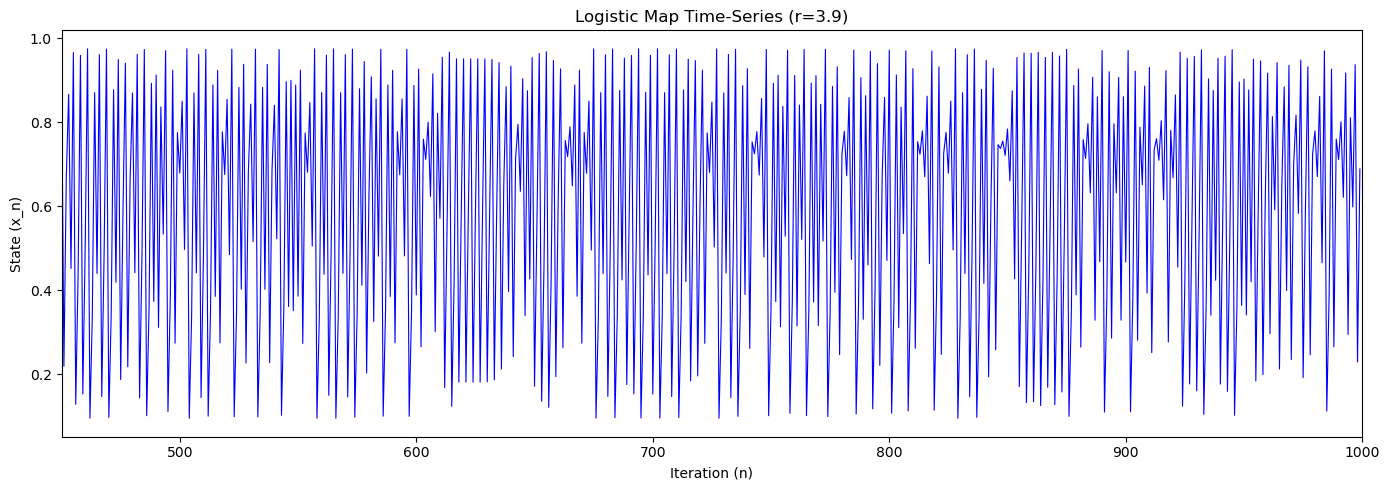

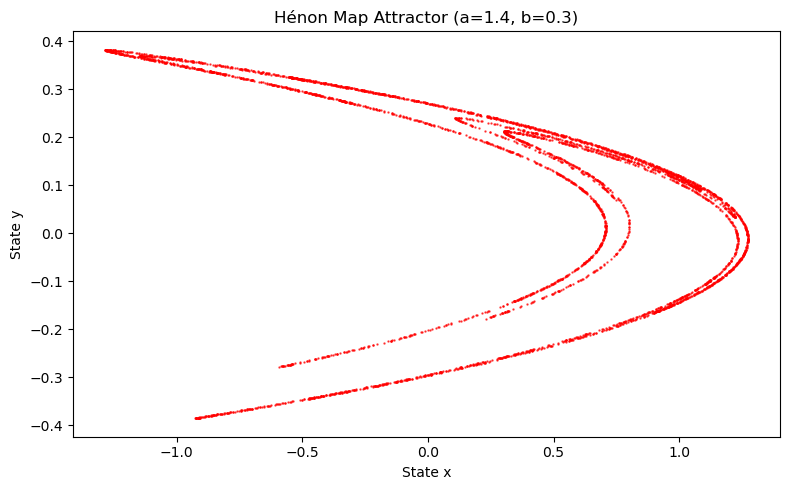

In [49]:
# Plot 1: Logistic Time-Series
fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(range(drop_logistic, iters_logistic), x_log_final, lw=0.8, color='blue')
ax1.set_title(f"Logistic Map Time-Series (r={r_logistic})")
ax1.set_xlabel("Iteration (n)")
ax1.set_ylabel("State (x_n)")
ax1.set_xlim(450, 1000)   # the bounds adjusted according to the limit (it should be changes if we changed the limit)


plt.tight_layout()
plt.show()


# Plot 2: Hénon Attractor
fig, ax2 = plt.subplots(figsize=(8, 5))

ax2.scatter(x_henon_final, y_henon_final, s=0.5, color='red', alpha=0.7)
ax2.set_title(f"Hénon Map Attractor (a={a_henon}, b={b_henon})")
ax2.set_xlabel("State x")
ax2.set_ylabel("State y")

plt.tight_layout()
plt.show()

### a more tight layout

In [50]:
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# # Plot 1: Logistic Time-Series
# ax1.plot(range(drop_logistic, iters_logistic), x_log_final, lw=0.8, color='blue')
# ax1.set_title(f"Logistic Map Time-Series (r={r_logistic})")
# ax1.set_xlabel("Iteration (n)")
# ax1.set_ylabel("State (x_n)")
# # ax1.set_ylim(-0.1, 1.09)
# ax1.set_xlim(450, 1000)

# # Plot 2: Hénon Attractor
# ax2.scatter(x_henon_final, y_henon_final, s=0.5, color='red', alpha=0.7)
# ax2.set_title(f"Hénon Map Attractor (a={a_henon}, b={b_henon})")
# ax2.set_xlabel("State x")
# ax2.set_ylabel("State y")

# plt.tight_layout()
# plt.show()

## A.4 Bifurcation Diagrams

In [11]:
def plot_logistic_bifurcation():
    r_values = np.arange(2.5, 4.0, 0.005)
    total_iters = 1000
    drop = 500
    
    plt.figure(figsize=(10, 6))
    
    for r in r_values:
        # We can reuse our function from above
        x_final = generate_logistic(r, 0.5, total_iters, drop)
        # Plot x_final against the current r value
        plt.plot([r] * len(x_final), x_final, ',k', alpha=0.1)
        
    plt.title("Logistic Map Bifurcation Diagram")
    plt.xlabel("Control Parameter (r)")
    plt.ylabel("Asymptotic States (x)")
    plt.show()

def plot_henon_bifurcation():
    a_values = np.arange(1.0, 1.4, 0.002)
    b = 0.3
    total_iters = 1000
    drop = 500
    
    plt.figure(figsize=(10, 6))
    
    for a in a_values:
        # For the bifurcation, we only plot the x variable against 'a'
        x_final, _ = generate_henon(a, b, 0.0, 0.0, total_iters, drop)
        plt.plot([a] * len(x_final), x_final, ',k', alpha=0.1)
        
    plt.title("Hénon Map Bifurcation Diagram (b=0.3)")
    plt.xlabel("Control Parameter (a)")
    plt.ylabel("Asymptotic States (x)")
    plt.show()

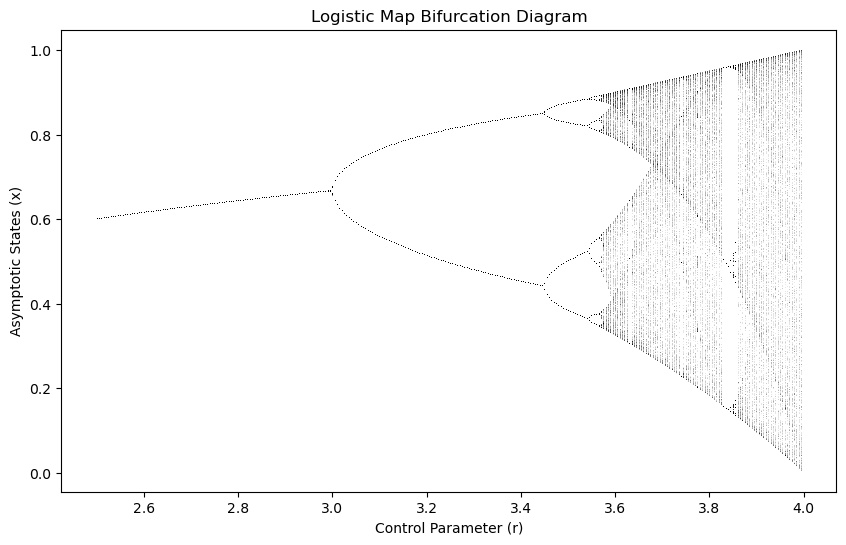

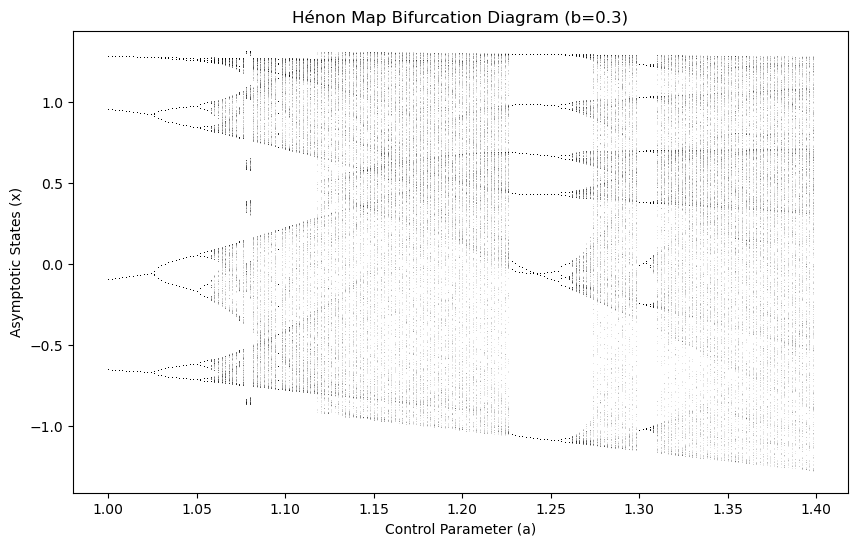

In [12]:
plot_logistic_bifurcation()
plot_henon_bifurcation()

---

# Part B — Continuous Chaotic Systems

## 1. The Core RK4 Integrator

In [13]:
def rk4_step(derivs, state, t, dt, params):
    """Calculates one RK4 step."""
    k1 = dt * derivs(t, state, *params)
    k2 = dt * derivs(t + dt/2, state + k1/2, *params)
    k3 = dt * derivs(t + dt/2, state + k2/2, *params)
    k4 = dt * derivs(t + dt, state + k3, *params)
    return state + (k1 + 2*k2 + 2*k3 + k4) / 6.0

def simulate_flow(derivs, initial_condition, T, dt, params):
    """Runs the simulation over time T."""
    steps = int(T / dt)
    states = np.zeros((steps, len(initial_condition)))
    states[0] = initial_condition
    time_vals = np.linspace(0, T, steps)
    
    for i in range(1, steps):
        states[i] = rk4_step(derivs, states[i-1], time_vals[i-1], dt, params)
        
    return time_vals, states

## 2. System Equations (Derivatives)

### B.2 Lorenz System

In [15]:
def lorenz(t, state, sigma, rho, beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return np.array([dx, dy, dz])

### B.3 Rössler System

In [16]:
def rossler(t, state, a, b, c):
    x, y, z = state
    dx = -y - z
    dy = x + a * y
    dz = b + z * (x - c)
    return np.array([dx, dy, dz])


### B.4 Chen System

In [17]:
def chen(t, state, a, b, c):
    x, y, z = state
    dx = a * (y - x)
    dy = (c - a) * x - x * z + c * y
    dz = x * y - b * z
    return np.array([dx, dy, dz])



### B.5 Hyperchaotic Rössler System (4D)

In [18]:
def hyper_rossler(t, state, a, b, c, d):
    x, y, z, w = state
    dx = -y - z
    dy = x + a * y + w
    dz = b + x * z
    dw = -c * z + d * w
    return np.array([dx, dy, dz, dw])

## 3. Execution & Settings

In [19]:
# Lorenz Settings
t_lor, states_lor = simulate_flow(lorenz, [1.0, 1.0, 1.0], 50, 0.01, (10, 28, 8/3))

# Rössler Settings
t_ros, states_ros = simulate_flow(rossler, [1.0, 1.0, 1.0], 250, 0.01, (0.2, 0.2, 5.7))

# Chen Settings (Stiffer system, using smaller dt)
t_chen, states_chen = simulate_flow(chen, [-0.1, 0.5, -0.6], 50, 0.005, (35, 3, 28))

# Hyperchaotic Rössler Settings
t_hyper, states_hyper = simulate_flow(hyper_rossler, [-10.0, -6.0, 0.0, 10.0], 250, 0.01, (0.25, 3.0, 0.5, 0.05))

## 4. Plotting

In [20]:
def plot_3d_system(time_vals, states, name):
    fig = plt.figure(figsize=(12, 5))
    
    # 3D Phase Space
    ax1 = fig.add_subplot(121, projection='3d')
    ax1.plot(states[:, 0], states[:, 1], states[:, 2], lw=0.5, color='b')
    ax1.set_title(f'{name} Phase Space')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    
    # Time Series
    ax2 = fig.add_subplot(122)
    ax2.plot(time_vals, states[:, 0], lw=0.8, label='x(t)')
    ax2.plot(time_vals, states[:, 1], lw=0.8, label='y(t)', alpha=0.7)
    ax2.plot(time_vals, states[:, 2], lw=0.8, label='z(t)', alpha=0.7)
    ax2.set_title(f'{name} Time Series')
    ax2.set_xlabel('Time')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

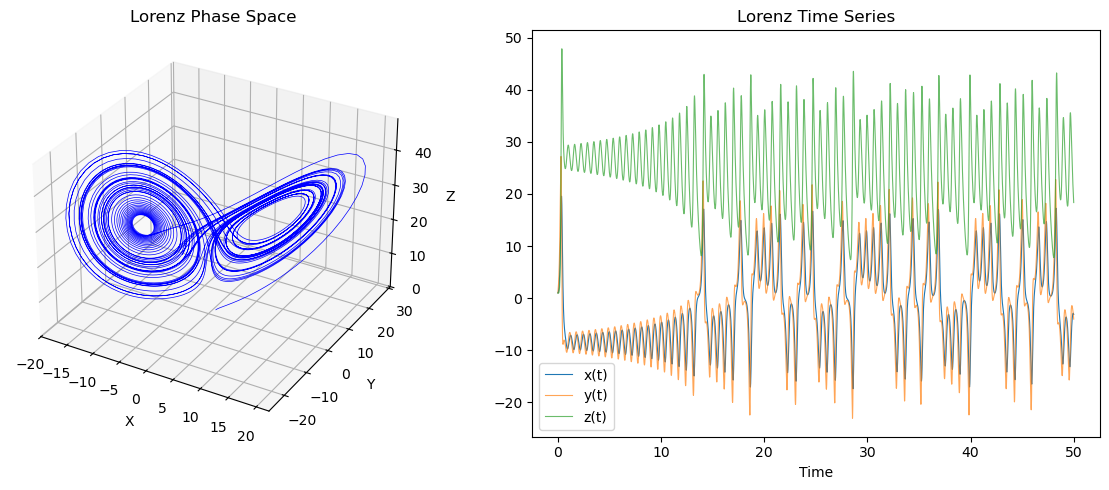

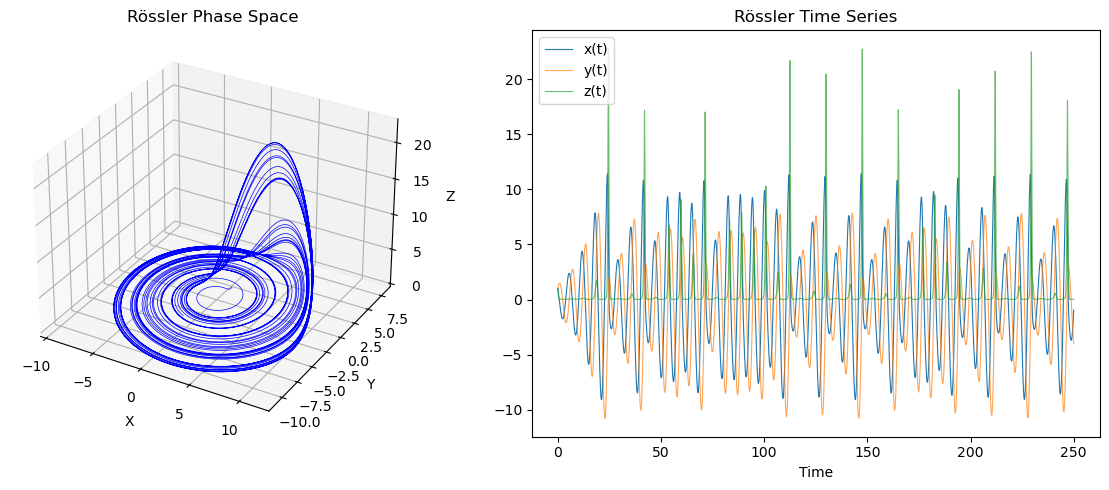

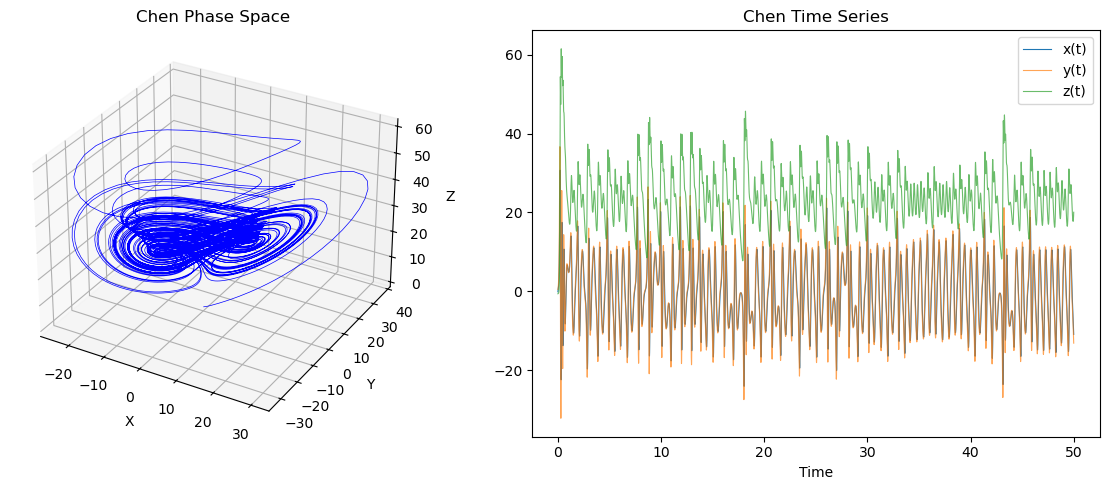

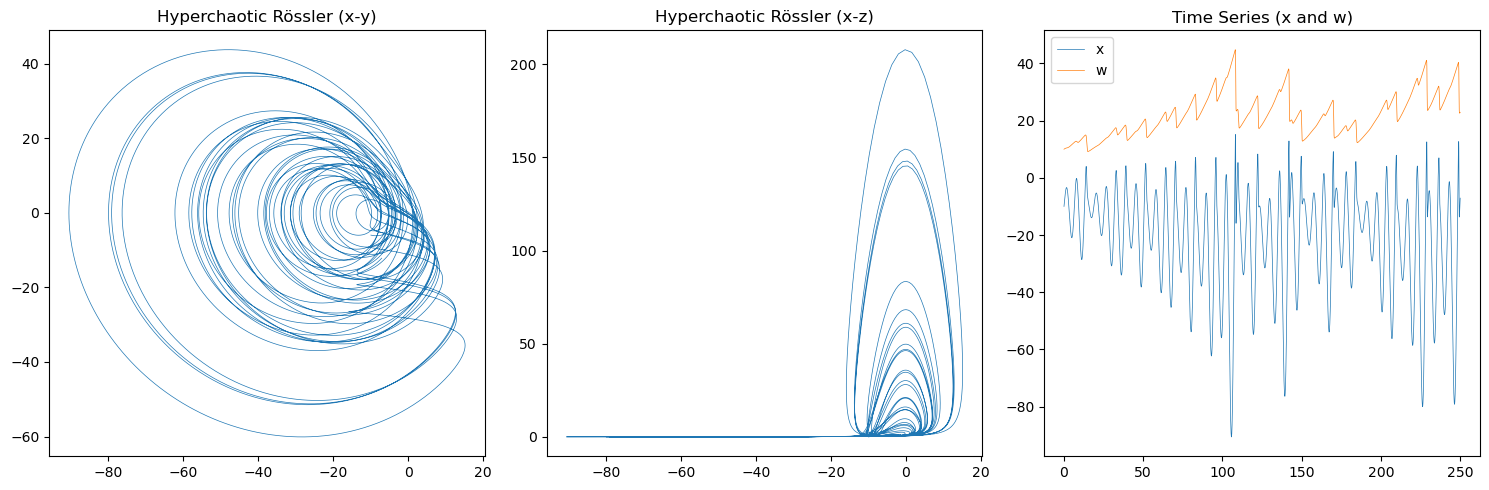

In [21]:
plot_3d_system(t_lor, states_lor, "Lorenz")
plot_3d_system(t_ros, states_ros, "Rössler")
plot_3d_system(t_chen, states_chen, "Chen")

# Generate 4D Hyperchaotic Plot (Projections)
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(131)
ax1.plot(states_hyper[:, 0], states_hyper[:, 1], lw=0.5)
ax1.set_title('Hyperchaotic Rössler (x-y)')

ax2 = fig.add_subplot(132)
ax2.plot(states_hyper[:, 0], states_hyper[:, 2], lw=0.5)
ax2.set_title('Hyperchaotic Rössler (x-z)')

ax3 = fig.add_subplot(133)
ax3.plot(time_vals_hyper := t_hyper, states_hyper[:, 0], lw=0.5, label='x')
ax3.plot(time_vals_hyper, states_hyper[:, 3], lw=0.5, label='w')
ax3.set_title('Time Series (x and w)')
ax3.legend()

plt.tight_layout()
plt.show()